In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report


In [72]:
random_state = 42

In [73]:
df = pd.read_csv('../Milestone 3 EDA/ppp_cleaned.csv')
df

,ProcessingMethod,BorrowerState,LoanStatus,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,...,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud,DateApproved_int,ForgivenessDate_int,LoanStatusDate_int
0,0.0,48.0,2.0,24,769358.78,769358.78,11.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12409.01,0,1588291200,1605830400,1608249600
1,0.0,48.0,2.0,24,736927.79,736927.79,11.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,10094.90,0,1588291200,1628726400,1632787200
2,0.0,48.0,2.0,24,691355.00,691355.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9218.07,0,1588291200,1612915200,1615939200
3,0.0,48.0,2.0,24,499871.00,499871.00,29.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,23803.38,0,1588291200,1631232000,1634342400
4,0.0,48.0,2.0,24,367437.00,367437.00,37.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,14697.48,0,1588291200,1617840000,1629158400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968527,0.0,56.0,2.0,24,150000.00,150000.00,54.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10000.00,0,1585872000,1607472000,1610496000
968528,0.0,56.0,2.0,24,150000.00,150000.00,31.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3452.38,0,1586822400,1604361600,1607385600
968529,1.0,56.0,2.0,60,150000.00,150000.00,54.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,29999.40,0,1613088000,1629158400,1631664000
968530,0.0,56.0,2.0,60,150000.00,150000.00,18.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,21428.57,0,1586908800,1645574400,1646697600


In [74]:
# Dropping features which leak data about the target
df.drop(columns=[
    'ForgivenessAmount',
	'ForgivenPercentage',
	'ForgivenessDate_int',
	'LoanStatus',
	'LoanStatusDate_int',
    'NotForgivenAmount',
	'DateApproved_int',
], inplace=True)

## Baseline

In [75]:
X = df.drop(columns='Fraud')
y = df['Fraud']

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    stratify=y,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Default settings on RF

In [77]:
# Train using optimal parameters
model = RandomForestClassifier(
    random_state=random_state,
    n_jobs=-1,
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
y_pred = model.predict(X_test)

In [79]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    193688
           1       0.00      0.00      0.00        19

    accuracy                           1.00    193707
   macro avg       0.50      0.50      0.50    193707
weighted avg       1.00      1.00      1.00    193707



c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [80]:
baseline_model_report_df = classification_report(y_test, y_pred, output_dict=True)

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

### Class Weight Balanced

In [81]:
# Train using optimal parameters
model = RandomForestClassifier(
    class_weight='balanced',
    random_state=random_state,
    n_jobs=-1
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
y_pred = model.predict(X_test)

In [83]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    193688
           1       0.00      0.00      0.00        19

    accuracy                           1.00    193707
   macro avg       0.50      0.50      0.50    193707
weighted avg       1.00      1.00      1.00    193707



c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [84]:
baseline_balanced_model_report_df = classification_report(y_test, y_pred, output_dict=True)

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

## Undersampling

In [85]:
fraud = df[df['Fraud'] == 1]
non_fraud = df[df['Fraud'] == 0]
len(fraud), len(non_fraud)

(95, 968437)

In [86]:
# Undersample majority class to a 1:10 ratio
non_fraud_downsampled = non_fraud.sample(n=len(fraud) * 10, random_state=random_state)
non_fraud_downsampled

,ProcessingMethod,BorrowerState,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,BusinessAgeDescription,...,PROCEED_Diff,UTILITIES_PROCEED_pct,PAYROLL_PROCEED_pct,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud
495859,1.0,25.0,60,175700.0,175700.0,52.0,0.0,0.0,0.0,1.0,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4748.57,0
751210,0.0,41.0,24,379200.0,379200.0,40.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9248.78,0
302413,0.0,14.0,24,238300.0,238300.0,14.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,8510.71,0
199402,0.0,8.0,24,742528.0,742528.0,37.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,19540.21,0
52948,1.0,5.0,60,882672.0,882672.0,37.0,1.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,18389.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294662,0.0,13.0,24,298700.0,298700.0,13.0,1.0,0.0,0.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,21335.71,0
204016,0.0,9.0,24,375100.0,375100.0,42.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,10717.14,0
387773,0.0,20.0,24,603200.0,603200.0,20.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,11827.45,0
378063,0.0,19.0,24,515000.0,515000.0,37.0,0.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,10510.20,0


In [87]:
# Combine and shuffle
df_reduced = pd.concat([fraud, non_fraud_downsampled]).sample(frac=1).reset_index(drop=True)
df_reduced

,ProcessingMethod,BorrowerState,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,BusinessAgeDescription,...,PROCEED_Diff,UTILITIES_PROCEED_pct,PAYROLL_PROCEED_pct,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud
0,0.0,5.0,24,362809.0,362809.0,45.0,1.0,0.0,0.0,4.0,...,0.0,0.07,0.76,0.00,0.17,0.0,0.00,0.00,6725.24,0
1,0.0,49.0,60,454400.0,454400.0,47.0,0.0,0.0,1.0,1.0,...,0.0,0.00,1.00,0.00,0.00,0.0,0.00,0.00,8573.58,0
2,0.0,47.0,24,286100.0,286100.0,46.0,1.0,0.0,0.0,1.0,...,0.0,0.00,0.80,0.20,0.00,0.0,0.00,0.00,7154.06,0
3,1.0,20.0,60,194695.0,194695.0,45.0,1.0,1.0,1.0,1.0,...,4.0,0.00,1.00,0.00,0.00,0.0,0.00,0.00,16224.17,0
4,0.0,10.0,24,155000.0,155000.0,16.0,1.0,0.0,0.0,1.0,...,0.0,0.00,1.00,0.00,0.00,0.0,0.00,0.00,9117.65,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1040,0.0,47.0,24,306022.0,306022.0,46.0,1.0,0.0,0.0,1.0,...,0.0,0.00,0.80,0.20,0.00,0.0,0.00,0.00,12240.90,0
1041,0.0,1.0,24,179000.0,179000.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.05,0.75,0.05,0.05,0.0,0.05,0.05,10326.92,0
1042,1.0,17.0,60,243717.0,243717.0,17.0,1.0,0.0,0.0,1.0,...,1.0,0.00,1.00,0.00,0.00,0.0,0.00,0.00,9026.48,0
1043,0.0,4.0,24,207600.0,207600.0,14.0,1.0,0.0,0.0,1.0,...,0.0,0.00,1.00,0.00,0.00,0.0,0.00,0.00,5463.16,0


In [88]:
X = df_reduced.drop(columns='Fraud')
y = df_reduced['Fraud']

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    stratify=y,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

In [90]:
cv = StratifiedKFold(n_splits=5)

### Recall as metric

In [91]:
# Parameter tuning
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 200)
    max_depth = trial.suggest_int("max_depth", 2, 32, log=True)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    
    model = RandomForestClassifier(
        class_weight='balanced',
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

top_5_recall_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_recall_df)

[I 2026-04-15 13:59:05,356] A new study created in memory with name: no-name-624299c0-4ab2-4580-80ce-639b1d0e74bb
[I 2026-04-15 13:59:05,540] Trial 0 finished with value: 0.32916666666666666 and parameters: {'n_estimators': 162, 'max_depth': 25, 'min_samples_split': 9}. Best is trial 0 with value: 0.32916666666666666.
[I 2026-04-15 13:59:05,588] Trial 1 finished with value: 0.5658333333333334 and parameters: {'n_estimators': 31, 'max_depth': 4, 'min_samples_split': 3}. Best is trial 1 with value: 0.5658333333333334.
[I 2026-04-15 13:59:05,683] Trial 2 finished with value: 0.605 and parameters: {'n_estimators': 103, 'max_depth': 4, 'min_samples_split': 10}. Best is trial 2 with value: 0.605.
[I 2026-04-15 13:59:05,840] Trial 3 finished with value: 0.6316666666666666 and parameters: {'n_estimators': 166, 'max_depth': 3, 'min_samples_split': 9}. Best is trial 3 with value: 0.6316666666666666.
[I 2026-04-15 13:59:05,904] Trial 4 finished with value: 0.645 and parameters: {'n_estimators': 6

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_split,params_n_estimators,state
72,72,0.696667,2026-04-15 13:59:10.444284,2026-04-15 13:59:10.492286,0 days 00:00:00.048002,2,10,36,COMPLETE
81,81,0.696667,2026-04-15 13:59:10.964893,2026-04-15 13:59:11.011893,0 days 00:00:00.047000,2,10,36,COMPLETE
93,93,0.696667,2026-04-15 13:59:11.495786,2026-04-15 13:59:11.543222,0 days 00:00:00.047436,2,9,37,COMPLETE
90,90,0.696667,2026-04-15 13:59:11.370273,2026-04-15 13:59:11.417284,0 days 00:00:00.047011,2,8,36,COMPLETE
55,55,0.695833,2026-04-15 13:59:09.529077,2026-04-15 13:59:09.560629,0 days 00:00:00.031552,2,9,22,COMPLETE


In [92]:
# Train using optimal parameters
model_1 = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=top_5_recall_df.head(1)['params_n_estimators'].item(),
    max_depth=top_5_recall_df.head(1)['params_max_depth'].item(),
    min_samples_split=top_5_recall_df.head(1)['params_min_samples_split'].item(),
    random_state=random_state
)
model_1.fit(X_train, y_train)

,n_estimators,36
,criterion,'gini'
,max_depth,2
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
y_pred = model_1.predict(X_test)

In [94]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.97      0.85      0.90       190
           1       0.33      0.74      0.45        19

    accuracy                           0.84       209
   macro avg       0.65      0.79      0.68       209
weighted avg       0.91      0.84      0.86       209



In [95]:
recall_model_report_df = classification_report(y_test, y_pred, output_dict=True)

## F1 as metric

In [96]:
# Parameter tuning
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 200)
    max_depth = trial.suggest_int("max_depth", 2, 32, log=True)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    
    model = RandomForestClassifier(
        class_weight='balanced',
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

top_5_f1_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_f1_df)

[I 2026-04-15 13:59:11,954] A new study created in memory with name: no-name-7ce9c413-77ed-429d-9f0a-166f1133cf63
[I 2026-04-15 13:59:12,044] Trial 0 finished with value: 0.5261878277451136 and parameters: {'n_estimators': 87, 'max_depth': 7, 'min_samples_split': 10}. Best is trial 0 with value: 0.5261878277451136.
[I 2026-04-15 13:59:12,188] Trial 1 finished with value: 0.39860398789536955 and parameters: {'n_estimators': 170, 'max_depth': 2, 'min_samples_split': 4}. Best is trial 0 with value: 0.5261878277451136.
[I 2026-04-15 13:59:12,299] Trial 2 finished with value: 0.5372745163623918 and parameters: {'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 5}. Best is trial 2 with value: 0.5372745163623918.
[I 2026-04-15 13:59:12,440] Trial 3 finished with value: 0.4200702678963548 and parameters: {'n_estimators': 131, 'max_depth': 29, 'min_samples_split': 9}. Best is trial 2 with value: 0.5372745163623918.
[I 2026-04-15 13:59:12,519] Trial 4 finished with value: 0.4537529137529

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_split,params_n_estimators,state
57,57,0.577625,2026-04-15 13:59:20.178072,2026-04-15 13:59:20.322092,0 days 00:00:00.144020,7,9,135,COMPLETE
81,81,0.566030,2026-04-15 13:59:23.418983,2026-04-15 13:59:23.592078,0 days 00:00:00.173095,7,9,155,COMPLETE
35,35,0.559104,2026-04-15 13:59:16.986589,2026-04-15 13:59:17.145180,0 days 00:00:00.158591,7,9,147,COMPLETE
59,59,0.556116,2026-04-15 13:59:20.481134,2026-04-15 13:59:20.607479,0 days 00:00:00.126345,7,8,97,COMPLETE
82,82,0.555456,2026-04-15 13:59:23.592078,2026-04-15 13:59:23.766361,0 days 00:00:00.174283,7,9,177,COMPLETE


In [97]:
# Train using optimal parameters
model_2 = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=top_5_f1_df.head(1)['params_n_estimators'].item(),
    max_depth=top_5_f1_df.head(1)['params_max_depth'].item(),
    min_samples_split=top_5_f1_df.head(1)['params_min_samples_split'].item(),
    random_state=random_state
)
model_2.fit(X_train, y_train)

,n_estimators,135
,criterion,'gini'
,max_depth,7
,min_samples_split,9
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [98]:
y_pred = model_2.predict(X_test)

In [99]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       190
           1       0.83      0.79      0.81        19

    accuracy                           0.97       209
   macro avg       0.91      0.89      0.90       209
weighted avg       0.97      0.97      0.97       209



In [100]:
f1_model_report_df = classification_report(y_test, y_pred, output_dict=True)

### Analyze reports

In [101]:
# 2. Convert and transpose
recall_report_df = pd.DataFrame(recall_model_report_df).transpose()
f1_report_df = pd.DataFrame(f1_model_report_df).transpose()

# 3. Combine multiple reports (e.g., adding a 'Model' column for identification)
combined_df = pd.concat([recall_report_df, f1_report_df], keys=['PPP RF optimized for Recall', 'PPP RF optimized for F1'])

In [102]:
combined_df

precision    recall  f1-score  \
PPP RF optimized for Recall 0              0.969880  0.847368  0.904494   
                            1              0.325581  0.736842  0.451613   
                            accuracy       0.837321  0.837321  0.837321   
                            macro avg      0.647730  0.792105  0.678054   
                            weighted avg   0.911307  0.837321  0.863323   
PPP RF optimized for F1     0              0.979058  0.984211  0.981627   
                            1              0.833333  0.789474  0.810811   
                            accuracy       0.966507  0.966507  0.966507   
                            macro avg      0.906195  0.886842  0.896219   
                            weighted avg   0.965810  0.966507  0.966099   

                                             support  
PPP RF optimized for Recall 0             190.000000  
                            1              19.000000  
                            accuracy        0.837321  
                            macro avg     209.000000  
                            weighted avg  209.000000  
PPP RF optimized for F1     0             190.000000  
                            1              19.000000  
                            accuracy        0.966507  
                            macro avg     209.000000  
                            weighted avg  209.000000

In [103]:
# Recall model
importances = model_1.feature_importances_
feature_names = df.drop(columns='Fraud').columns
feature_imp_recall_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
feature_imp_recall_df

,Feature,Gini Importance
2,Term,0.169246
33,PROCEED_Per_Job,0.133524
0,ProcessingMethod,0.098336
12,UTILITIES_PROCEED,0.088130
9,BusinessAgeDescription,0.076464
25,PROCEED_Diff,0.062314
1,BorrowerState,0.052368
20,OriginatingLenderState,0.052261
24,TOTAL_PROCEED,0.026009
19,BusinessType,0.025394


In [104]:
# Recall model
importances = model_2.feature_importances_
feature_names = df.drop(columns='Fraud').columns
feature_imp_f1_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
feature_imp_f1_df

,Feature,Gini Importance
2,Term,1.490771e-01
33,PROCEED_Per_Job,1.176388e-01
24,TOTAL_PROCEED,5.453749e-02
20,OriginatingLenderState,5.431923e-02
11,JobsReported,5.228614e-02
10,ProjectState,5.117704e-02
4,CurrentApprovalAmount,5.047935e-02
3,InitialApprovalAmount,4.898695e-02
13,PAYROLL_PROCEED,4.799869e-02
9,BusinessAgeDescription,4.745650e-02


## Multivariate Analysis

In [105]:
df_reduced.head(5)

,ProcessingMethod,BorrowerState,Term,InitialApprovalAmount,CurrentApprovalAmount,ServicingLenderState,RuralUrbanIndicator,HubzoneIndicator,LMIIndicator,BusinessAgeDescription,...,PROCEED_Diff,UTILITIES_PROCEED_pct,PAYROLL_PROCEED_pct,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job,Fraud
0,0.0,5.0,24,362809.0,362809.0,45.0,1.0,0.0,0.0,4.0,...,0.0,0.07,0.76,0.0,0.17,0.0,0.0,0.0,6725.24,0
1,0.0,49.0,60,454400.0,454400.0,47.0,0.0,0.0,1.0,1.0,...,0.0,0.00,1.00,0.0,0.00,0.0,0.0,0.0,8573.58,0
2,0.0,47.0,24,286100.0,286100.0,46.0,1.0,0.0,0.0,1.0,...,0.0,0.00,0.80,0.2,0.00,0.0,0.0,0.0,7154.06,0
3,1.0,20.0,60,194695.0,194695.0,45.0,1.0,1.0,1.0,1.0,...,4.0,0.00,1.00,0.0,0.00,0.0,0.0,0.0,16224.17,0
4,0.0,10.0,24,155000.0,155000.0,16.0,1.0,0.0,0.0,1.0,...,0.0,0.00,1.00,0.0,0.00,0.0,0.0,0.0,9117.65,0


In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

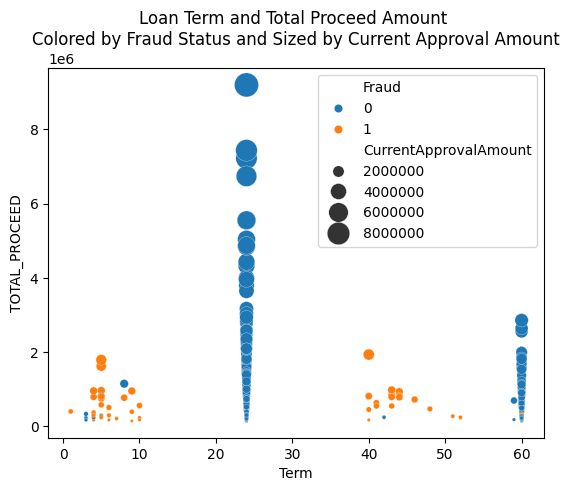

In [123]:
minroot = df_reduced['CurrentApprovalAmount'].min()
maxroot = df_reduced['CurrentApprovalAmount'].max()
maxbubble = 300
ax = sns.scatterplot(data = df_reduced, x = "Term", y = "TOTAL_PROCEED", size = "CurrentApprovalAmount", hue='Fraud', sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("Term")
ax.set_ylabel("TOTAL_PROCEED")
plt.title("Loan Term and Total Proceed Amount \nColored by Fraud Status and Sized by Current Approval Amount")
plt.savefig('ppp_figs/bubble_plot')
None

<Axes: >

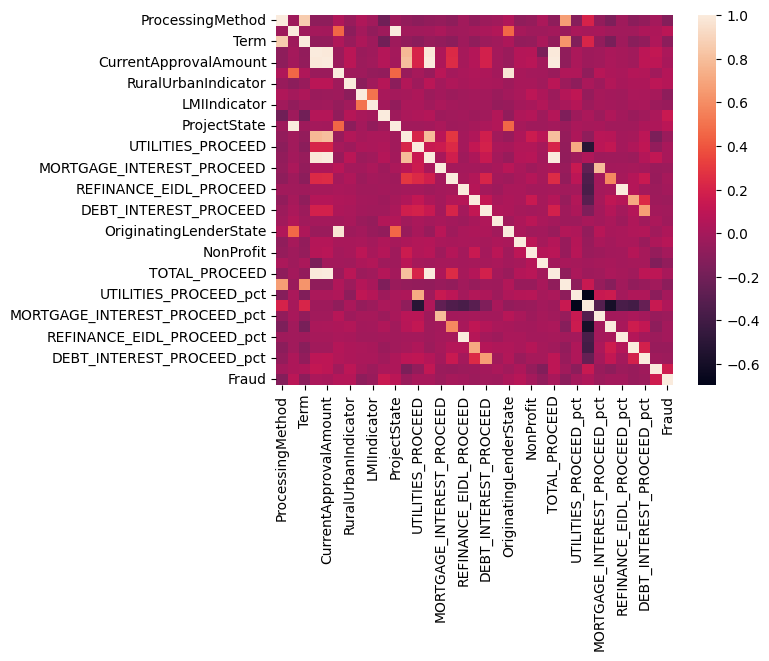

In [124]:
sns.heatmap(df_reduced.corr())